# CSE437 Data Science — Phase 4
## Model Development, Evaluation, and Model Comparison
**Project:** *Evaluation of Vision–Language Baselines on a Defined VizWiz-VQA Subset: Answer Accuracy and Error Analysis for Low-Quality and Unanswerable Images*


In [ ]:
!pip -q install -U transformers accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 43.4 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import json, re, math, random, time, warnings, zipfile, tarfile
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
from transformers import ViltProcessor, ViltForQuestionAnswering, BlipProcessor, BlipForQuestionAnswering
warnings.filterwarnings('ignore')
RANDOM_STATE=42
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)
IN_COLAB=False
try:
    import google.colab
    IN_COLAB=True
except Exception:
    pass
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
print('Running in Colab:', IN_COLAB)
print('Device:', DEVICE)

Running in Colab: True
Device: cpu


In [ ]:
PROJECT_ROOT = Path("/content") if IN_COLAB else Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "vizwiz_phase4"
OUTPUT_DIR = PROJECT_ROOT / "phase4_outputs"
FIGURE_DIR = PROJECT_ROOT / "phase4_figures"

for p in (DATA_DIR, OUTPUT_DIR, FIGURE_DIR):
    p.mkdir(parents=True, exist_ok=True)
VQA_EVAL_N = 100
VAL_ZIP_DRIVE_PATH = "/content/drive/MyDrive/val.zip"

print("Data directory:", DATA_DIR)
print("Expected Drive ZIP:", VAL_ZIP_DRIVE_PATH)

Data directory: /content/vizwiz_phase4
Expected Drive ZIP: /content/drive/MyDrive/val.zip


In [ ]:
import zipfile
import tarfile
import os

def extract_archive(path, destination):
    path = Path(path)
    destination = Path(destination)
    destination.mkdir(parents=True, exist_ok=True)

    n = path.name.lower()

    try:
        if n.endswith(".zip"):
            with zipfile.ZipFile(path, "r") as z:
                z.extractall(destination)
            print("Extracted:", path)
            return True

        if n.endswith((".tar", ".tar.gz", ".tgz")):
            with tarfile.open(path, "r:*") as t:
                t.extractall(destination)
            print("Extracted:", path)
            return True

    except Exception as e:
        print("Extraction failed for", path, ":", e)

    return False


# PART A: Uploading Annotations.zip

if IN_COLAB:
    from google.colab import files

    print("PART A")
    print("Upload ONLY Annotations.zip here.")
    print("Do not upload the large val.zip through this browser uploader.")

    uploaded = files.upload()

    for filename, content in uploaded.items():
        target = DATA_DIR / Path(filename).name
        target.write_bytes(content)
        print("Saved:", target)

        if target.name.lower().endswith((".zip", ".tar", ".tar.gz", ".tgz")):
            extract_archive(target, DATA_DIR)

else:
    print("Not running in Colab. Put annotation files in:", DATA_DIR)



# PART B: Mounting Google Drive
if IN_COLAB:
    from google.colab import drive

    print("\nPART B")
    print("Mounting Google Drive for val.zip...")
    drive.mount("/content/drive", force_remount=False)

    preferred = Path(VAL_ZIP_DRIVE_PATH)

    if preferred.exists():
        val_zip_path = preferred
        print("Found val.zip at preferred path:", val_zip_path)

    else:
        print("val.zip was not found at:", preferred)
        print("Searching My Drive for a file named val.zip ...")

        drive_root = Path("/content/drive/MyDrive")
        matches = list(drive_root.rglob("val.zip")) if drive_root.exists() else []

        if len(matches) == 1:
            val_zip_path = matches[0]
            print("Found val.zip:", val_zip_path)

        elif len(matches) > 1:
            print("Multiple val.zip files were found:")
            for m in matches:
                print(" -", m)
            val_zip_path = matches[0]
            print("Using the first one:", val_zip_path)

        else:
            val_zip_path = None
            print("\nIMPORTANT:")
            print("No val.zip was found in Google Drive.")
            print("Uploading val.zip to My Drive, then reruning THIS cell.")
            print("Recommended location: My Drive/val.zip")

    if val_zip_path is not None:
        existing_val_images = list(DATA_DIR.rglob("VizWiz_val_*.jpg"))

        if len(existing_val_images) >= 100:
            print(
                f"Validation images already extracted: {len(existing_val_images):,}. "
                "Skipping re-extraction."
            )
        else:
            print("Extracting validation images from Google Drive...")
            extract_archive(val_zip_path, DATA_DIR)

            extracted_count = len(list(DATA_DIR.rglob("VizWiz_val_*.jpg")))
            print(f"Validation JPG files detected after extraction: {extracted_count:,}")

PART A
Upload ONLY Annotations.zip here.
Do not upload the large val.zip through this browser uploader.


Saving Annotations (1).zip to Annotations (1).zip
Saved: /content/vizwiz_phase4/Annotations (1).zip
Extracted: /content/vizwiz_phase4/Annotations (1).zip

PART B
Mounting Google Drive for val.zip...
Mounted at /content/drive
Found val.zip at preferred path: /content/drive/MyDrive/val.zip
Extracting validation images from Google Drive...
Extracted: /content/drive/MyDrive/val.zip
Validation JPG files detected after extraction: 7,750


In [ ]:
def find_json(split):
    patterns = {
        "train": ["train.json", "*train*.json"],
        "val": ["val.json", "validation.json", "*val*.json", "*valid*.json"],
    }[split]

    candidates = []
    for pattern in patterns:
        candidates.extend(DATA_DIR.rglob(pattern))

    bad_words = {
        "summary", "metrics", "prediction", "processed",
        "phase3_processing_summary"
    }

    candidates = [
        p for p in candidates
        if not any(word in p.name.lower() for word in bad_words)
    ]
    candidates = [p for p in candidates if "test" not in p.name.lower()]

    return candidates[0] if candidates else None


def find_image_by_name(name):
    if not name:
        return None

    filename = Path(str(name)).name
    hits = list(DATA_DIR.rglob(filename))

    return hits[0] if hits else None


train_json = find_json("train")
val_json = find_json("val")

validation_jpgs = list(DATA_DIR.rglob("VizWiz_val_*.jpg"))

print("Train JSON:", train_json)
print("Val JSON:", val_json)
print(f"Validation image files currently available: {len(validation_jpgs):,}")

if train_json is None or val_json is None:
    raise FileNotFoundError(
        "train.json and/or val.json were not found. "
        "Rerun Step 2 and upload Annotations.zip."
    )

if len(validation_jpgs) == 0:
    print(
        "\nWARNING: Annotation files are ready, but validation images are still missing.\n"
        "Putting val.zip in Google Drive (preferably My Drive/val.zip) and reruning Step 2."
    )
else:
    print("Annotation files and validation images are ready.")

Train JSON: /content/vizwiz_phase4/train.json
Val JSON: /content/vizwiz_phase4/val.json
Validation image files currently available: 7,750
Annotation files and validation images are ready.


## 3. Load and reconstruct the Phase 3 features

In [ ]:
UNANSWERABLE_TERMS={'unanswerable','unsuitable',"can't tell",'cannot tell','not sure','unknown','n/a','none','illegible','too blurry','blurry'}
OCR_KEYWORDS={'read','text','say','says','written','write','label','sign','price','date','expiry','expiration','number','word','name','brand','screen','document','letter'}
COUNT_KEYWORDS={'how many','number of','count'}
COLOR_KEYWORDS={'color','colour'}
YES_NO_STARTERS={'is','are','am','was','were','do','does','did','can','could','will','would','has','have','had','should'}

def normalize_text(v):
    if v is None:return ''
    v=str(v).lower().strip(); v=re.sub(r'\s+',' ',v); v=re.sub(r"[^\w\s'-]",'',v); return v.strip()

def extract_answer_text(x):
    if isinstance(x,str): return normalize_text(x)
    if isinstance(x,dict):
        for k in ('answer','text','label'):
            if k in x:return normalize_text(x[k])
    return ''

def extract_answers(r):
    raw=r.get('answers',r.get('answer',[])); raw=[raw] if isinstance(raw,(str,dict)) else raw
    return [a for a in (extract_answer_text(x) for x in raw) if a] if isinstance(raw,list) else []

def consensus_answer(a): return Counter(a).most_common(1)[0][0] if a else ''

def infer_answerable(r,a):
    for k in ('answerable','is_answerable','answerability'):
        if k in r:
            try:return int(bool(int(r[k])))
            except Exception:
                t=normalize_text(r[k])
                if t in {'yes','true','answerable'}: return 1
                if t in {'no','false','unanswerable'}: return 0
    if a:
        u=sum(x in UNANSWERABLE_TERMS for x in a)
        return int(u<max(1,math.ceil(len(a)/2)))
    return np.nan

def answer_agreement(a): return Counter(a).most_common(1)[0][1]/len(a) if a else np.nan

def answer_entropy(a):
    if not a:return np.nan
    c=np.array(list(Counter(a).values()),dtype=float); p=c/c.sum(); return float(-(p*np.log2(p)).sum())

def question_type(q):
    q=normalize_text(q)
    if not q:return 'missing'
    f=q.split()[0]
    if any(q.startswith(k) for k in COUNT_KEYWORDS):return 'counting'
    if f in YES_NO_STARTERS:return 'yes_no'
    if f in {'what','which','who','where','when','why','how'}:return f
    return 'other'

def load_json_records(path):
    with open(path,'r',encoding='utf-8') as f: obj=json.load(f)
    if isinstance(obj,list):return obj
    if isinstance(obj,dict):
        for k in ('annotations','data','questions','records'):
            if k in obj and isinstance(obj[k],list):return obj[k]
    raise ValueError('Unsupported JSON structure')

def flatten(records,split):
    rows=[]
    for i,r in enumerate(records):
        if not isinstance(r,dict):continue
        image=r.get('image',r.get('image_id',r.get('filename',r.get('file_name',''))))
        q=r.get('question',r.get('query','')); a=extract_answers(r)
        rows.append({'split':split,'record_index':i,'image':str(image),'question':normalize_text(q),'answers_list':a,'consensus_answer':consensus_answer(a),'answerable':infer_answerable(r,a),'num_human_answers':len(a),'answer_agreement':answer_agreement(a),'answer_entropy':answer_entropy(a)})
    return pd.DataFrame(rows)

train_df=flatten(load_json_records(train_json),'train'); val_df=flatten(load_json_records(val_json),'val')
df=pd.concat([train_df,val_df],ignore_index=True)
df['question_word_count']=df['question'].str.split().str.len().fillna(0).astype(int)
df['question_char_count']=df['question'].str.len().fillna(0).astype(int)
df['question_first_word']=df['question'].str.split().str[0].fillna('missing')
df['question_type']=df['question'].map(question_type)
df['is_ocr_related']=df['question'].map(lambda x:int(any(k in x for k in OCR_KEYWORDS)))
df['is_counting_question']=df['question'].map(lambda x:int(any(k in x for k in COUNT_KEYWORDS)))
df['is_color_question']=df['question'].map(lambda x:int(any(k in x for k in COLOR_KEYWORDS)))
df['is_yes_no_question']=df['question_first_word'].isin(YES_NO_STARTERS).astype(int)
print('Loaded:',df.shape)
display(df.head())

Loaded: (24842, 18)


,split,record_index,image,question,answers_list,consensus_answer,answerable,num_human_answers,answer_agreement,answer_entropy,question_word_count,question_char_count,question_first_word,question_type,is_ocr_related,is_counting_question,is_color_question,is_yes_no_question
0,train,0,VizWiz_train_00000000.jpg,what's the name of this product,"[basil leaves, basil leaves, basil, basil, bas...",basil leaves,1,10,0.7,0.881291,6,31,what's,other,1,0,0,0
1,train,1,VizWiz_train_00000001.jpg,can you tell me what is in this can please,"[soda, coca cola, coca cola, unanswerable, una...",coca cola,1,10,0.3,2.446439,10,42,can,yes_no,0,0,0,1
2,train,2,VizWiz_train_00000002.jpg,is this enchilada sauce or is this tomatoes th...,"[these tomatoes not enchilada sauce, tomatoes,...",tomatoes,1,10,0.7,1.156780,10,53,is,yes_no,0,0,0,1
3,train,3,VizWiz_train_00000003.jpg,what is the captcha on this screenshot,"[t36m, t36m, t36m, t 3 6 m, t36m, t36m, t36m, ...",t36m,1,10,0.8,0.921928,7,38,what,what,1,0,0,0
4,train,4,VizWiz_train_00000004.jpg,what is this item,"[solar garden light, solar garden light, solar...",solar garden light,1,10,0.8,0.921928,4,17,what,what,0,0,0,0


In [ ]:
feature_cols=['question_type','question_first_word','question_word_count','question_char_count','is_ocr_related','is_counting_question','is_color_question','is_yes_no_question','answer_agreement','answer_entropy']
model_df=df.dropna(subset=['answerable']).copy()
X_train=model_df[model_df['split']=='train'][feature_cols]; y_train=model_df[model_df['split']=='train']['answerable'].astype(int)
X_val=model_df[model_df['split']=='val'][feature_cols]; y_val=model_df[model_df['split']=='val']['answerable'].astype(int)
cat=['question_type','question_first_word']; num=['question_word_count','question_char_count','answer_agreement','answer_entropy']; binary=['is_ocr_related','is_counting_question','is_color_question','is_yes_no_question']
try:ohe=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
except TypeError:ohe=OneHotEncoder(handle_unknown='ignore',sparse=False)
prep=ColumnTransformer([
 ('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('ohe',ohe)]),cat),
 ('num',Pipeline([('imp',SimpleImputer(strategy='median')),('scale',StandardScaler())]),num),
 ('bin',Pipeline([('imp',SimpleImputer(strategy='most_frequent'))]),binary)])
models={
 'Logistic Regression':Pipeline([('prep',prep),('model',LogisticRegression(max_iter=1000,random_state=RANDOM_STATE))]),
 'Random Forest':Pipeline([('prep',prep),('model',RandomForestClassifier(n_estimators=200,random_state=RANDOM_STATE,class_weight='balanced',n_jobs=-1))])}

In [ ]:
aux=[]
for name,m in models.items():
    print('Training',name); m.fit(X_train,y_train); pred=m.predict(X_val)
    aux.append({'Model':name,'Accuracy':accuracy_score(y_val,pred),'Precision':precision_score(y_val,pred,zero_division=0),'Recall':recall_score(y_val,pred,zero_division=0),'F1':f1_score(y_val,pred,zero_division=0)})
aux_comparison=pd.DataFrame(aux).sort_values('F1',ascending=False)
display(aux_comparison.round(4))

Training Logistic Regression
Training Random Forest


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.7833,0.8087,0.8920,0.8483
1,Random Forest,0.7812,0.8597,0.8102,0.8342


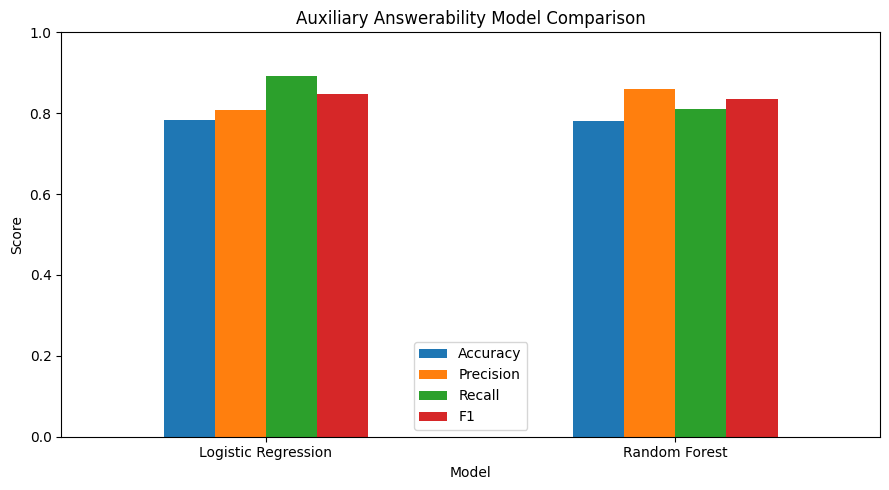

In [ ]:
aux_comparison.set_index('Model')[['Accuracy','Precision','Recall','F1']].plot(kind='bar',figsize=(9,5))
plt.title('Auxiliary Answerability Model Comparison'); plt.ylabel('Score'); plt.ylim(0,1); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# Part B — Main vision-language model comparison
The main experiment evaluates **ViLT** and **BLIP VQA** on the same VizWiz validation examples. Metrics include exact match, soft VQA accuracy, answerable accuracy, unanswerable handling, and OCR-related accuracy.

In [ ]:

validation_image_paths = list(DATA_DIR.rglob("VizWiz_val_*.jpg"))
validation_image_index = {p.name: str(p) for p in validation_image_paths}

print(f"Indexed validation images: {len(validation_image_index):,}")

val_eval = df[df["split"] == "val"].copy()

val_eval["image_path"] = val_eval["image"].map(
    lambda name: validation_image_index.get(Path(str(name)).name, "")
)

val_eval["image_exists"] = val_eval["image_path"].ne("")
available = val_eval[val_eval["image_exists"]].copy()

print("Validation annotation rows:", len(val_eval))
print("Validation images matched to annotation rows:", len(available))

if available.empty:
    raise FileNotFoundError(
        "No validation images matched the annotation filenames. "
        "Checking that val.zip was extracted successfully in Step 2."
    )

eval_n = min(VQA_EVAL_N, len(available))
vqa_eval = available.sample(
    eval_n,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("VQA evaluation N:", len(vqa_eval))

display(
    vqa_eval[
        ["image", "question", "consensus_answer", "answerable"]
    ].head()
)

Indexed validation images: 7,750
Validation annotation rows: 4319
Validation images matched to annotation rows: 4319
VQA evaluation N: 100


,image,question,consensus_answer,answerable
0,VizWiz_val_00000314.jpg,can you please tell me not to compare skin cel...,unanswerable,0
1,VizWiz_val_00004284.jpg,what is this,unanswerable,0
2,VizWiz_val_00000734.jpg,what color is this and what is it,brown teddy bear,1
3,VizWiz_val_00000151.jpg,okay i moved the camera a little to the right ...,unanswerable,0
4,VizWiz_val_00000109.jpg,what is the expiration date on this bus pass,unanswerable,0


In [ ]:
def normalize_vqa_answer(t):
    t=normalize_text(t); t=re.sub(r'\b(a|an|the)\b',' ',t); return re.sub(r'\s+',' ',t).strip()
def exact_match_score(pred,answers):
    p=normalize_vqa_answer(pred); refs=[normalize_vqa_answer(a) for a in answers]; return float(p in refs) if refs else np.nan
def soft_vqa_score(pred,answers):
    p=normalize_vqa_answer(pred); refs=[normalize_vqa_answer(a) for a in answers]; return min(sum(p==a for a in refs)/3.0,1.0)
def predicts_unanswerable(pred):
    return int(normalize_vqa_answer(pred) in {'unanswerable','unknown','cannot tell','cant tell','not sure','unsure','none'})

In [ ]:
print('Loading ViLT...')
vilt_processor=ViltProcessor.from_pretrained('dandelin/vilt-b32-finetuned-vqa')
vilt_model=ViltForQuestionAnswering.from_pretrained('dandelin/vilt-b32-finetuned-vqa').to(DEVICE); vilt_model.eval()

Loading ViLT...


preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/136k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  470MB            

model.safetensors: downloading bytes:           |  0.00B            

ViltForQuestionAnswering(
  (vilt): ViltModel(
    (embeddings): ViltEmbeddings(
      (text_embeddings): TextEmbeddings(
        (word_embeddings): Embedding(30522, 768)
        (position_embeddings): Embedding(40, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (patch_embeddings): ViltPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
      )
      (token_type_embeddings): Embedding(2, 768)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViltEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViltLayer(
          (attention): ViltAttention(
            (attention): ViltSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=76

In [ ]:
def predict_vilt(path,q):
    image=Image.open(path).convert('RGB'); enc=vilt_processor(images=image,text=q,return_tensors='pt'); enc={k:v.to(DEVICE) for k,v in enc.items()}
    with torch.no_grad(): out=vilt_model(**enc)
    return vilt_model.config.id2label[out.logits.argmax(-1).item()]
vilt_predictions=[]
for i,row in vqa_eval.iterrows():
    try:vilt_predictions.append(predict_vilt(row['image_path'],row['question']))
    except Exception:vilt_predictions.append('__ERROR__')
    if (i+1)%10==0:print('ViLT',i+1,'/',len(vqa_eval))

ViLT 10 / 100
ViLT 20 / 100
ViLT 30 / 100
ViLT 40 / 100
ViLT 50 / 100
ViLT 60 / 100
ViLT 70 / 100
ViLT 80 / 100
ViLT 90 / 100
ViLT 100 / 100


In [ ]:
vilt_model.to('cpu')
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('Loading BLIP...')
blip_processor=BlipProcessor.from_pretrained('Salesforce/blip-vqa-base')
blip_model=BlipForQuestionAnswering.from_pretrained('Salesforce/blip-vqa-base').to(DEVICE); blip_model.eval()

Loading BLIP...


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.54GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

BlipForQuestionAnswering(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-05, e

In [ ]:
def predict_blip(path,q):
    image=Image.open(path).convert('RGB'); inp=blip_processor(images=image,text=q,return_tensors='pt').to(DEVICE)
    with torch.no_grad(): ids=blip_model.generate(**inp,max_new_tokens=10)
    return blip_processor.decode(ids[0],skip_special_tokens=True)
blip_predictions=[]
for i,row in vqa_eval.iterrows():
    try:blip_predictions.append(predict_blip(row['image_path'],row['question']))
    except Exception:blip_predictions.append('__ERROR__')
    if (i+1)%10==0:print('BLIP',i+1,'/',len(vqa_eval))

BLIP 10 / 100
BLIP 20 / 100
BLIP 30 / 100
BLIP 40 / 100
BLIP 50 / 100
BLIP 60 / 100
BLIP 70 / 100
BLIP 80 / 100
BLIP 90 / 100
BLIP 100 / 100


In [ ]:
results_df=vqa_eval.copy(); results_df['ViLT_prediction']=vilt_predictions; results_df['BLIP_prediction']=blip_predictions
display(results_df[['image','question','consensus_answer','ViLT_prediction','BLIP_prediction']].head(10))

,image,question,consensus_answer,ViLT_prediction,BLIP_prediction
0,VizWiz_val_00000314.jpg,can you please tell me not to compare skin cel...,unanswerable,no,yes
1,VizWiz_val_00004284.jpg,what is this,unanswerable,phone,bottle
2,VizWiz_val_00000734.jpg,what color is this and what is it,brown teddy bear,yellow,brown
3,VizWiz_val_00000151.jpg,okay i moved the camera a little to the right ...,unanswerable,yes,yes
4,VizWiz_val_00000109.jpg,what is the expiration date on this bus pass,unanswerable,0,5
5,VizWiz_val_00000596.jpg,does this shoe have a stiletto heel,yes,yes,yes
6,VizWiz_val_00002347.jpg,i turned the box to the next side can you tell...,womens 1 daily,no,no
7,VizWiz_val_00003237.jpg,what is in this bottle,unanswerable,nothing,vitamin water
8,VizWiz_val_00002118.jpg,can you tell what soda this is,dr pepper 10,no,yes
9,VizWiz_val_00003281.jpg,what is this,ford logo,frisbee,ford


In [ ]:
def evaluate_predictions(frame,pred_col):
    exact=[]; soft=[]; unans=[]
    for _,r in frame.iterrows():
        exact.append(exact_match_score(r[pred_col],r['answers_list'])); soft.append(soft_vqa_score(r[pred_col],r['answers_list']))
        if int(r['answerable'])==0: unans.append(predicts_unanswerable(r[pred_col]))
    return {'Exact Match':float(np.nanmean(exact)),'Soft VQA Accuracy':float(np.nanmean(soft)),'Unanswerable Handling':float(np.mean(unans)) if unans else np.nan}
rows=[]
for model,pcol in [('ViLT','ViLT_prediction'),('BLIP','BLIP_prediction')]:
    overall=evaluate_predictions(results_df,pcol)
    ans=evaluate_predictions(results_df[results_df['answerable']==1],pcol)
    ocr=evaluate_predictions(results_df[results_df['is_ocr_related']==1],pcol) if (results_df['is_ocr_related']==1).any() else {}
    rows.append({'Model':model,'Exact Match':overall['Exact Match'],'Soft VQA Accuracy':overall['Soft VQA Accuracy'],'Answerable Soft Accuracy':ans['Soft VQA Accuracy'],'Unanswerable Handling':overall['Unanswerable Handling'],'OCR Soft Accuracy':ocr.get('Soft VQA Accuracy',np.nan),'Evaluated N':len(results_df)})
vqa_comparison=pd.DataFrame(rows).sort_values('Soft VQA Accuracy',ascending=False)
display(vqa_comparison.round(4))

,Model,Exact Match,Soft VQA Accuracy,Answerable Soft Accuracy,Unanswerable Handling,OCR Soft Accuracy,Evaluated N
1,BLIP,0.31,0.2567,0.3381,0.0333,0.1111,100
0,ViLT,0.21,0.1533,0.1952,0.0333,0.0794,100


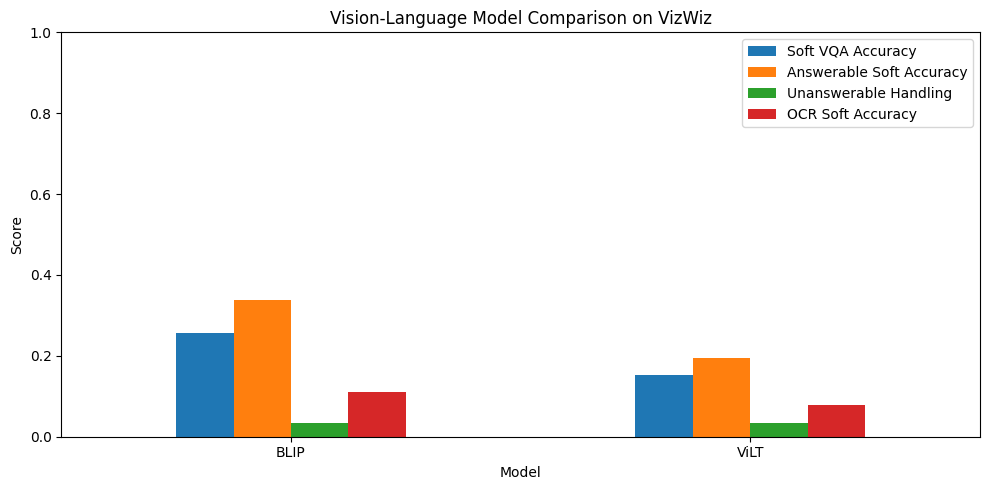

In [ ]:
vqa_comparison.set_index('Model')[['Soft VQA Accuracy','Answerable Soft Accuracy','Unanswerable Handling','OCR Soft Accuracy']].plot(kind='bar',figsize=(10,5))
plt.title('Vision-Language Model Comparison on VizWiz'); plt.ylabel('Score'); plt.ylim(0,1); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 4. Qualitative error analysis

In [ ]:
def error_type(r,pcol):
    p=normalize_vqa_answer(r[pcol])
    if p=='__error__':return 'inference_error'
    if int(r['answerable'])==0:
        return 'correct_abstention' if predicts_unanswerable(p) else 'hallucinated_or_unsupported_answer'
    if r['is_ocr_related']==1 and soft_vqa_score(p,r['answers_list'])==0:return 'ocr_related_error'
    return 'wrong_answer' if soft_vqa_score(p,r['answers_list'])==0 else 'correct'
for m,p in [('ViLT','ViLT_prediction'),('BLIP','BLIP_prediction')]: results_df[m+'_error_type']=results_df.apply(lambda r:error_type(r,p),axis=1)
print('ViLT errors'); display(results_df['ViLT_error_type'].value_counts().to_frame('count'))
print('BLIP errors'); display(results_df['BLIP_error_type'].value_counts().to_frame('count'))

ViLT errors


,count
ViLT_error_type,
wrong_answer,42
hallucinated_or_unsupported_answer,29
correct,18
ocr_related_error,10
correct_abstention,1


BLIP errors


,count
BLIP_error_type,
wrong_answer,32
hallucinated_or_unsupported_answer,29
correct,27
ocr_related_error,11
correct_abstention,1


In [ ]:
display(results_df[['image','question','consensus_answer','answerable','ViLT_prediction','ViLT_error_type','BLIP_prediction','BLIP_error_type']].sample(min(15,len(results_df)),random_state=RANDOM_STATE))

,image,question,consensus_answer,answerable,ViLT_prediction,ViLT_error_type,BLIP_prediction,BLIP_error_type
83,VizWiz_val_00000620.jpg,have the check disk command completed and were...,unanswerable,0,yes,hallucinated_or_unsupported_answer,yes,hallucinated_or_unsupported_answer
53,VizWiz_val_00003999.jpg,what is this,water bottle,1,water,correct,water bottle,correct
70,VizWiz_val_00001808.jpg,what is this,unanswerable,0,frisbee,hallucinated_or_unsupported_answer,frisbee,hallucinated_or_unsupported_answer
45,VizWiz_val_00001912.jpg,what kind of rice is this,4 cheese,1,yellow,wrong_answer,baby,wrong_answer
44,VizWiz_val_00002423.jpg,what setting is this set for,unanswerable,0,reading,hallucinated_or_unsupported_answer,skateboarding,hallucinated_or_unsupported_answer
39,VizWiz_val_00002154.jpg,what kind of keyboard is this who makes it,apple,1,apple,correct,apple,correct
22,VizWiz_val_00000744.jpg,what is this thing,unanswerable,0,cat,hallucinated_or_unsupported_answer,stuffed animal,hallucinated_or_unsupported_answer
80,VizWiz_val_00000371.jpg,what is this and what color is it,teddy bear brown,1,blue,wrong_answer,brown,wrong_answer
10,VizWiz_val_00000969.jpg,is there a name of this card,unanswerable,0,yes,hallucinated_or_unsupported_answer,no,hallucinated_or_unsupported_answer
0,VizWiz_val_00000314.jpg,can you please tell me not to compare skin cel...,unanswerable,0,no,hallucinated_or_unsupported_answer,yes,hallucinated_or_unsupported_answer


## 5. Best model selection

In [ ]:
best=vqa_comparison.sort_values(['Soft VQA Accuracy','Unanswerable Handling','OCR Soft Accuracy'],ascending=False).iloc[0]
other=vqa_comparison.sort_values(['Soft VQA Accuracy','Unanswerable Handling','OCR Soft Accuracy'],ascending=False).iloc[1]
BEST_MODEL=best['Model']
print('Selected best model:',BEST_MODEL) codeseg5 next
print(f"{BEST_MODEL} achieved soft VQA accuracy {best['Soft VQA Accuracy']:.3f}, compared with {other['Soft VQA Accuracy']:.3f} for {other['Model']}. Its answerable soft accuracy was {best['Answerable Soft Accuracy']:.3f}, unanswerable handling was {best['Unanswerable Handling']:.3f}, and OCR soft accuracy was {best['OCR Soft Accuracy']:.3f}.")

Selected best model: BLIP
BLIP achieved soft VQA accuracy 0.257, compared with 0.153 for ViLT. Its answerable soft accuracy was 0.338, unanswerable handling was 0.033, and OCR soft accuracy was 0.111.


In [ ]:
print(f"Checking for val.zip at: {VAL_ZIP_DRIVE_PATH}")
!ls {VAL_ZIP_DRIVE_PATH}

Checking for val.zip at: /content/drive/MyDrive/val.zip
/content/drive/MyDrive/val.zip


In [ ]:
results_export=results_df.copy(); results_export['answers_json']=results_export['answers_list'].map(lambda x:json.dumps(x,ensure_ascii=False)); results_export=results_export.drop(columns=['answers_list'],errors='ignore')
results_export.to_csv(OUTPUT_DIR/'phase4_vqa_predictions_and_errors.csv',index=False)
vqa_comparison.to_csv(OUTPUT_DIR/'phase4_vqa_model_comparison.csv',index=False)
aux_comparison.to_csv(OUTPUT_DIR/'phase4_auxiliary_model_comparison.csv',index=False)
print('Saved outputs in',OUTPUT_DIR)

Saved outputs in /content/phase4_outputs
